In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
matches=pd.read_csv('../data/matches.csv')
deliveries=pd.read_csv('../data/deliveries.csv')

In [3]:
matches.shape

(1095, 20)

In [4]:
deliveries.shape

(260920, 17)

In [5]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [6]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


Analyze match / player CSVs to get top
scorers, strike rates, team win rates.

In [10]:
top_score=deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False)
top_score.head()

batter
V Kohli      8014
S Dhawan     6769
RG Sharma    6630
DA Warner    6567
SK Raina     5536
Name: batsman_runs, dtype: int64

In [11]:
# so from above we interpret Virat Kohli is the top scorer from the given data

In [14]:
runs=deliveries.groupby('batter')['batsman_runs'].sum()
balls=deliveries.groupby('batter')['ball'].count()
strike_rate=(runs/balls)*100
strike_rate.sort_values(ascending=False).head()

batter
L Wood             300.000000
B Stanlake         250.000000
J Fraser-McGurk    220.000000
R Sai Kishore      216.666667
Umar Gul           205.263158
dtype: float64

In [21]:
# L Wood have highest strike rate of about 300

In [23]:
wins=matches['winner'].value_counts()
matches_played=pd.concat([matches['team1'],matches['team2']]).value_counts()
win_percentage=(wins/matches_played)*100
win_percentage.sort_values(ascending=False)

Rising Pune Supergiant         62.500000
Gujarat Titans                 62.222222
Chennai Super Kings            57.983193
Mumbai Indians                 55.172414
Lucknow Super Giants           54.545455
Delhi Capitals                 52.747253
Kolkata Knight Riders          52.191235
Rajasthan Royals               50.678733
Sunrisers Hyderabad            48.351648
Royal Challengers Bangalore    48.333333
Royal Challengers Bengaluru    46.666667
Kings XI Punjab                46.315789
Gujarat Lions                  43.333333
Punjab Kings                   42.857143
Kochi Tuskers Kerala           42.857143
Delhi Daredevils               41.614907
Deccan Chargers                38.666667
Rising Pune Supergiants        35.714286
Pune Warriors                  26.086957
Name: count, dtype: float64

In [24]:
# RPS & GT have the highest winning percentage based on their previous wins

Visualize per-season and per-player
metrics.

In [25]:
season_data=matches[['id','season']]
deliveries=deliveries.merge(season_data, left_on='match_id',right_on='id')
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder,id,season
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN,335982,2007/08
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2007/08
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN,335982,2007/08
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2007/08
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN,335982,2007/08


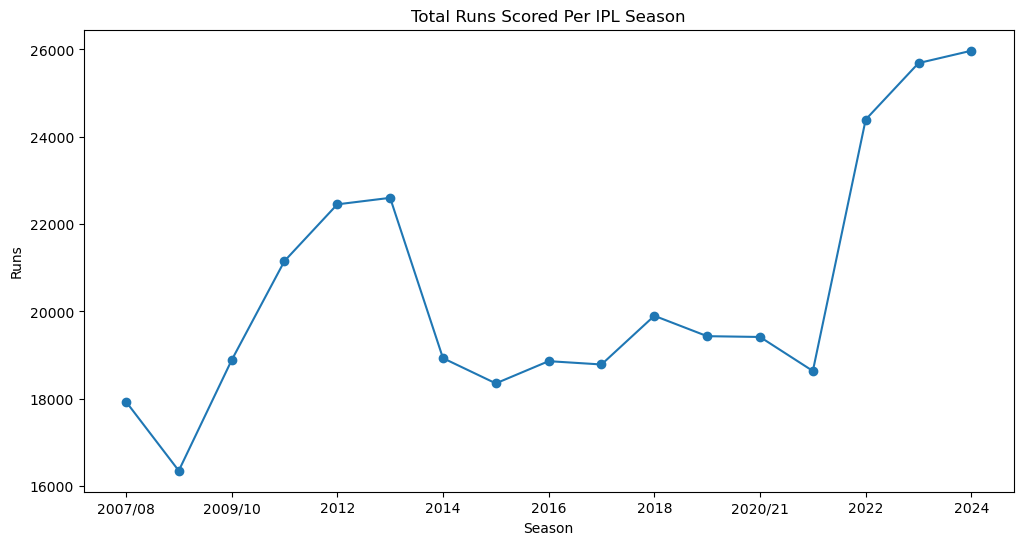

season
2007/08    17937
2009       16353
2009/10    18883
2011       21154
2012       22453
2013       22602
2014       18931
2015       18353
2016       18862
2017       18786
2018       19901
2019       19434
2020/21    19416
2021       18637
2022       24395
2023       25688
2024       25971
Name: total_runs, dtype: int64


In [30]:
#total runs scored in each ipl season
season_runs=deliveries.groupby('season')['total_runs'].sum()
plt.figure(figsize=(12,6))
season_runs.plot(marker='o')
plt.title("Total Runs Scored Per IPL Season")
plt.xlabel('Season')
plt.ylabel('Runs')
plt.savefig('../outputs/total_runs.png')
plt.show()
print(season_runs)

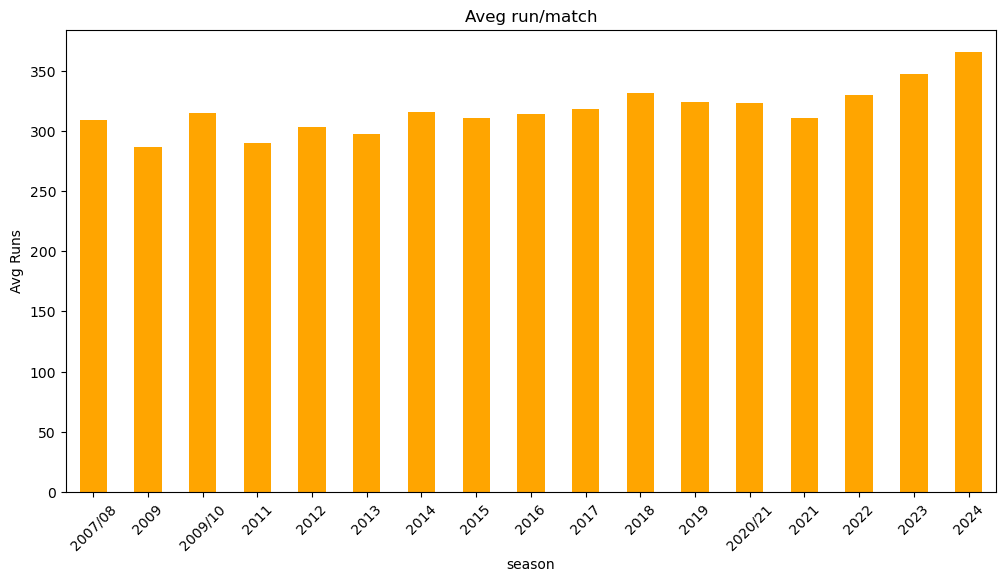

In [34]:
#Avg runs/match
rpm=deliveries.groupby(['season','match_id'])['total_runs'].sum().reset_index()
season_avg=rpm.groupby('season')['total_runs'].mean()
plt.figure(figsize=(12,6))
season_avg.plot(kind='bar',color='orange')
plt.title('Aveg run/match')
plt.xticks(rotation=45)
plt.ylabel('Avg Runs')
plt.savefig('../outputs/avg_runs_match.png')
plt.show()

In [35]:
#Orange Cap Winner
sbr=deliveries.groupby(['season','batter'])['batsman_runs'].sum().reset_index()
oc=sbr.loc[sbr.groupby('season')['batsman_runs'].idxmax()]
oc

,season,batter,batsman_runs
115,2007/08,SE Marsh,616
229,2009,ML Hayden,572
446,2009/10,SR Tendulkar,618
502,2011,CH Gayle,608
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
1088,2014,RV Uthappa,660
1148,2015,DA Warner,562
1383,2016,V Kohli,973
1422,2017,DA Warner,641


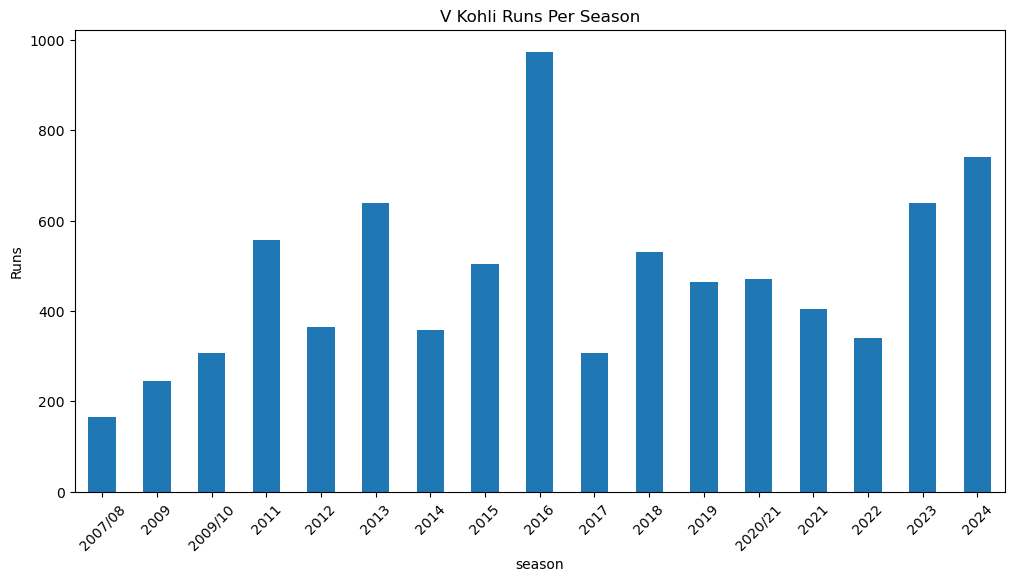

In [48]:
#Runs per Season
player = "V Kohli"
kohli = deliveries[deliveries['batter'] == player]
kohli_season_runs = kohli.groupby('season')['batsman_runs'].sum()
plt.figure(figsize=(12,6))
kohli_season_runs.plot(kind='bar')
plt.title(f"{player} Runs Per Season")
plt.ylabel("Runs")
plt.xticks(rotation=45)
plt.savefig('../outputs/virat_runs.png')
plt.show()

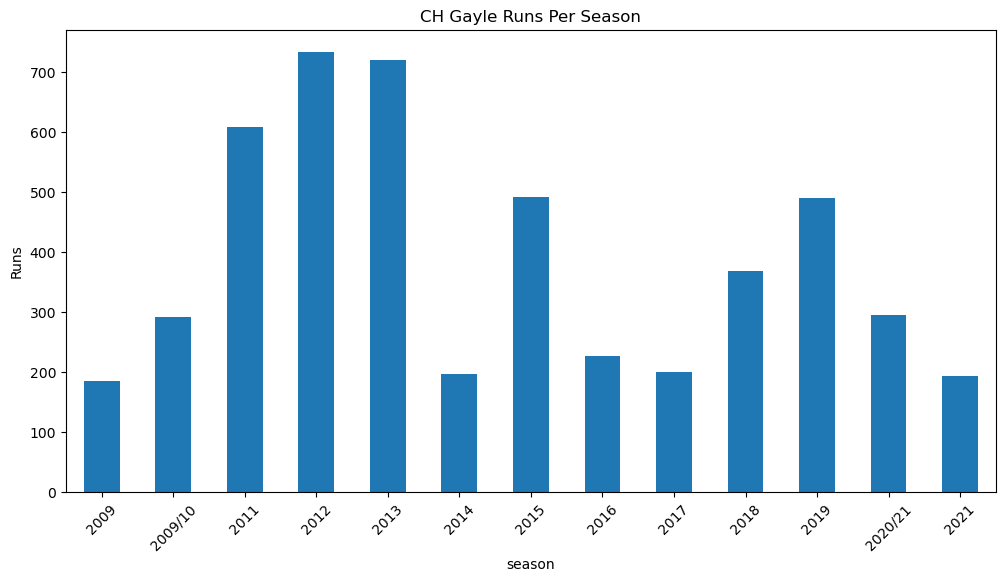

In [40]:
player = "CH Gayle"
kohli = deliveries[deliveries['batter'] == player]
kohli_season_runs = kohli.groupby('season')['batsman_runs'].sum()
plt.figure(figsize=(12,6))
kohli_season_runs.plot(kind='bar')
plt.title(f"{player} Runs Per Season")
plt.ylabel("Runs")
plt.xticks(rotation=45)
plt.savefig('../outputs/gayle_runs.png')
plt.show()

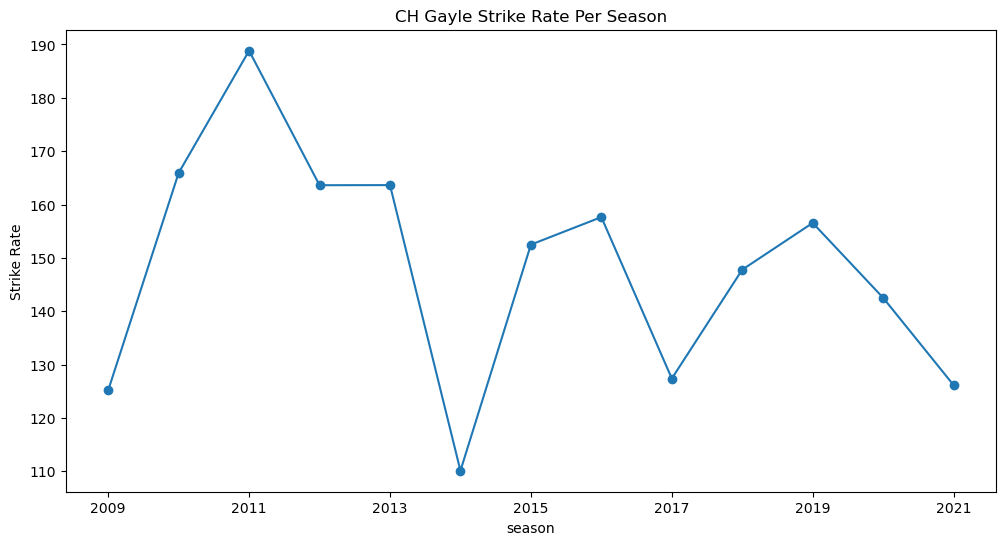

In [46]:
#Strike Rate Per Season
kohli = deliveries[deliveries['batter'] == player]
runs = kohli.groupby('season')['batsman_runs'].sum()
balls = kohli[kohli['extra_runs'] == 0].groupby('season')['ball'].count()
strike_rate = (runs / balls) * 100
plt.figure(figsize=(12,6))
strike_rate.plot(marker='o')
plt.title(f"{player} Strike Rate Per Season")
plt.ylabel("Strike Rate")
plt.savefig('../outputs/strike_rate_season.png')
plt.show()

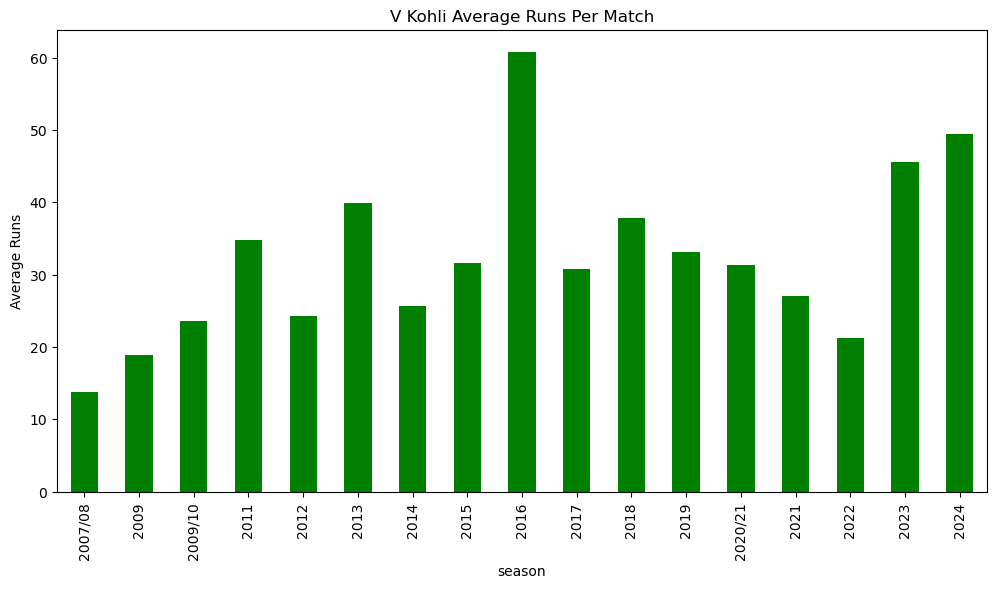

In [50]:
# Player Consistency
match_runs = kohli.groupby(['season','match_id'])['batsman_runs'].sum().reset_index()
avg_runs = match_runs.groupby('season')['batsman_runs'].mean()
plt.figure(figsize=(12,6))
avg_runs.plot(kind='bar', color='green')
plt.title(f"{player} Average Runs Per Match")
plt.ylabel("Average Runs")
plt.savefig('../outputs/player_consistency.png')
plt.show()

In [51]:
players = ["V Kohli", "RG Sharma", "MS Dhoni"]

In [52]:
player_data = deliveries[deliveries['batter'].isin(players)]

In [53]:
print(player_data)

        match_id  inning                 batting_team           bowling_team  \
132       335982       2  Royal Challengers Bangalore  Kolkata Knight Riders   
133       335982       2  Royal Challengers Bangalore  Kolkata Knight Riders   
134       335982       2  Royal Challengers Bangalore  Kolkata Knight Riders   
137       335982       2  Royal Challengers Bangalore  Kolkata Knight Riders   
138       335982       2  Royal Challengers Bangalore  Kolkata Knight Riders   
...          ...     ...                          ...                    ...   
260280   1426310       1  Royal Challengers Bengaluru       Rajasthan Royals   
260282   1426310       1  Royal Challengers Bengaluru       Rajasthan Royals   
260286   1426310       1  Royal Challengers Bengaluru       Rajasthan Royals   
260287   1426310       1  Royal Challengers Bengaluru       Rajasthan Royals   
260288   1426310       1  Royal Challengers Bengaluru       Rajasthan Royals   

        over  ball   batter     bowler 

In [55]:
season_runs = player_data.groupby(['season','batter'])['batsman_runs'].sum().reset_index()
pivot_runs = season_runs.pivot(index='season', columns='batter', values='batsman_runs').fillna(0)

<Figure size 1200x600 with 0 Axes>

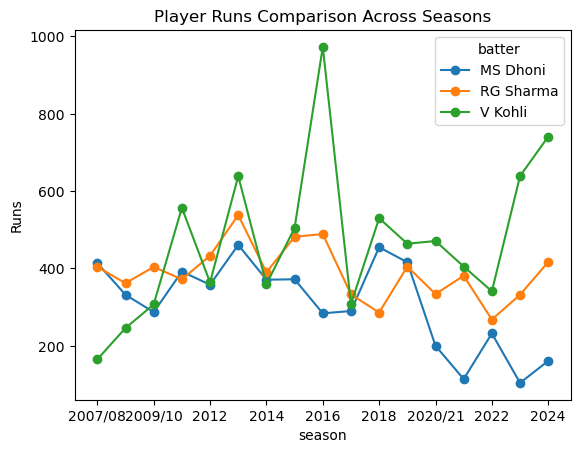

In [62]:
plt.figure(figsize=(12,6))
pivot_runs.plot(marker='o')
plt.title("Player Runs Comparison Across Seasons")
plt.ylabel("Runs")
plt.savefig('../outputs/player_consistency_season.png')
plt.show()

In [58]:
# Strike Rate Comparison
legal_deliveries = player_data[player_data['extra_runs'] == 0]
runs = player_data.groupby(['season','batter'])['batsman_runs'].sum()
balls = legal_deliveries.groupby(['season','batter'])['ball'].count()

In [60]:
strike_rate = (runs/balls)*100
strike_rate = strike_rate.reset_index()
pivot_sr = strike_rate.pivot(index='season', columns='batter', values=0)

<Figure size 1200x600 with 0 Axes>

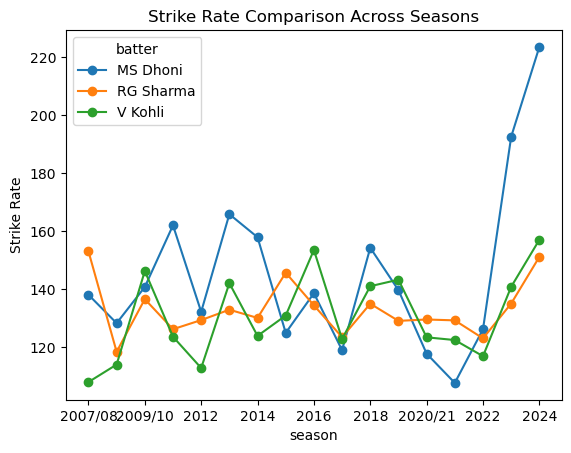

In [63]:
plt.figure(figsize=(12,6))
pivot_sr.plot(marker='o')
plt.title("Strike Rate Comparison Across Seasons")
plt.ylabel("Strike Rate")
plt.savefig('../outputs/strike_rate_compa_season.png')
plt.show()

In [65]:
# Consistency
match_runs = player_data.groupby(['season','batter','match_id'])['batsman_runs'].sum().reset_index()
avg_runs = match_runs.groupby(['season','batter'])['batsman_runs'].mean().reset_index()
pivot_avg = avg_runs.pivot(index='season', columns='batter', values='batsman_runs')

<Figure size 1200x600 with 0 Axes>

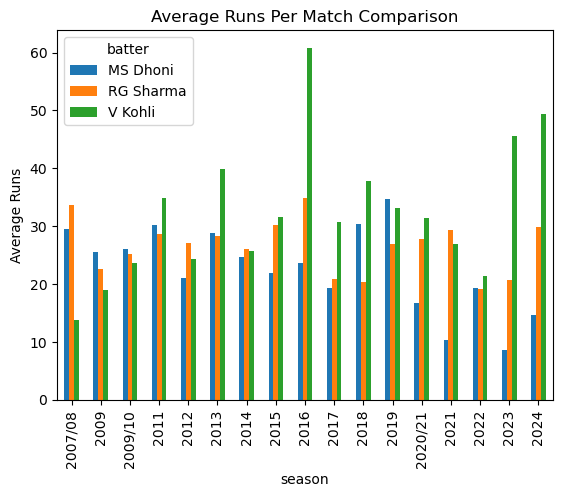

In [67]:
plt.figure(figsize=(12,6))
pivot_avg.plot(kind='bar')
plt.title("Average Runs Per Match Comparison")
plt.ylabel("Average Runs")
plt.savefig('../outputs/avg_run_compa_match.png')
plt.show()